In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
from math import comb

In [3]:
# Compute a(n) using the combinatorial formula
def a(n):
    if n == 1:
        return 1
    if n < 1:
        return 0
    total = 0
    #implementing floor and ceiling division now
    for k in range(int(n + 4) // 5, int(n) // 4+1):
        total += comb(k, 5 * k - n)
    return total

# Known partition approximation function
def approximate_p(n):
    """Approximate partition function using Hardy-Ramanujan formula"""
    if n < 0:
        return 0
    if n == 0:
        return 1
    return (1 / (4 * n * np.sqrt(3))) * np.exp(np.pi * np.sqrt(2 * n / 3))

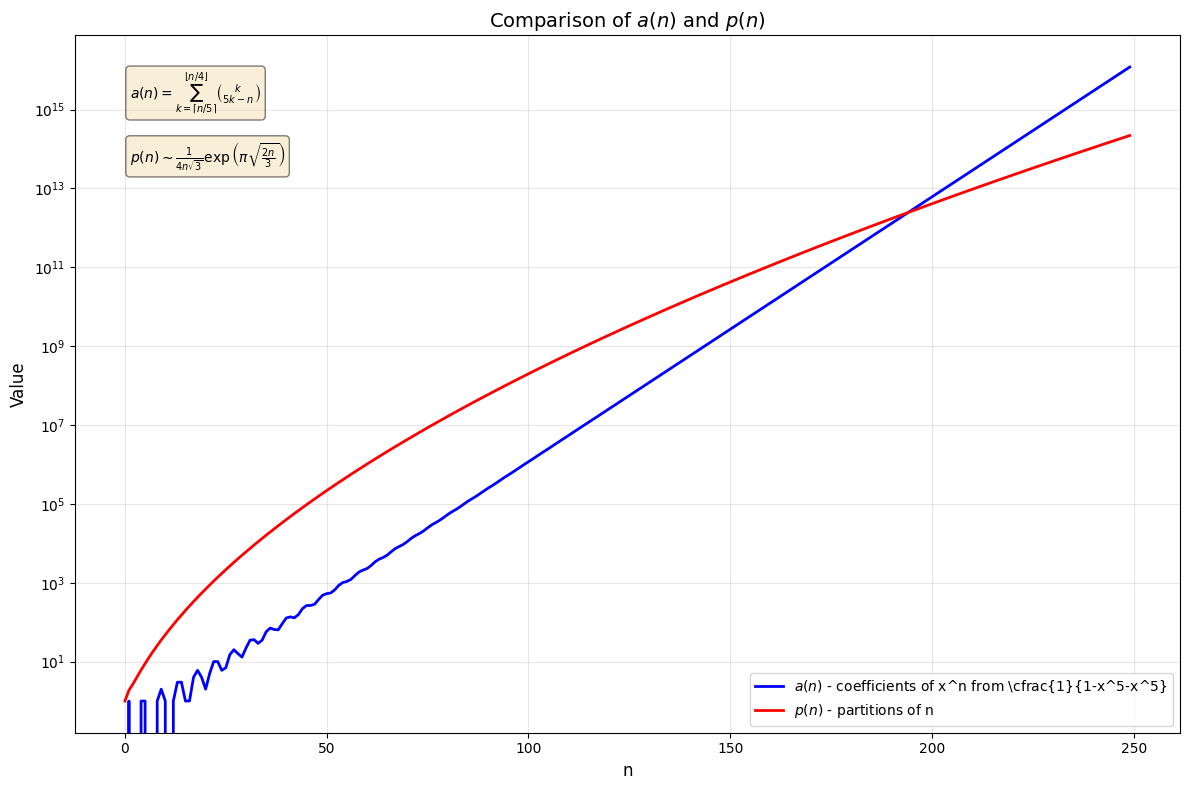

In [4]:
# Generate data
n_values = np.arange(0, 250)
a_values = [a(n) for n in n_values]
p_values = [(approximate_p(n)) for n in n_values]

# Create the plot
plt.figure(figsize=(12, 8))

# Plot both functions
plt.plot(n_values, a_values, 'b-', linewidth=2, label=r'$a(n)$ - coefficients of x^n from \cfrac{1}{1-x^5-x^5}')
plt.plot(n_values, p_values, 'r-', linewidth=2, label=r'$p(n)$ - partitions of n')

plt.yscale('log')
# plt.ylim((1, max(max(a_values), max(p_values)) * 10))

plt.xlabel('n', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(r'Comparison of $a(n)$ and $p(n)$', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Add some key observations in text
plt.text(0.05, 0.95, r'$a(n) = \sum_{k=\lceil n/5 \rceil}^{\lfloor n/4 \rfloor} \binom{k}{5k-n}$', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.text(0.05, 0.85, r'$p(n) \sim \frac{1}{4n\sqrt{3}} \exp\left(\pi\sqrt{\frac{2n}{3}}\right)$', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

In [5]:
# Print some key values around the crossover
print("Key values around crossover:")
print("n\ta(n)\t\tp(n)")
print("-" * 50)
for n in range(40, 70):
    a_val = a(n)
    p_val = approximate_p(n)
    relation = ">" if a_val > p_val else "<"
    print(f"{n}\t{a_val:.2e}\t{p_val:.2e}  {relation}")

Key values around crossover:
n	a(n)		p(n)
--------------------------------------------------
40	1.28e+02	4.01e+04  <
41	1.36e+02	4.78e+04  <
42	1.29e+02	5.70e+04  <
43	1.56e+02	6.78e+04  <
44	2.20e+02	8.04e+04  <
45	2.64e+02	9.53e+04  <
46	2.65e+02	1.13e+05  <
47	2.85e+02	1.33e+05  <
48	3.76e+02	1.57e+05  <
49	4.84e+02	1.85e+05  <
50	5.29e+02	2.18e+05  <
51	5.50e+02	2.56e+05  <
52	6.61e+02	3.00e+05  <
53	8.60e+02	3.51e+05  <
54	1.01e+03	4.10e+05  <
55	1.08e+03	4.79e+05  <
56	1.21e+03	5.59e+05  <
57	1.52e+03	6.52e+05  <
58	1.87e+03	7.59e+05  <
59	2.09e+03	8.82e+05  <
60	2.29e+03	1.02e+06  <
61	2.73e+03	1.19e+06  <
62	3.39e+03	1.38e+06  <
63	3.96e+03	1.59e+06  <
64	4.38e+03	1.84e+06  <
65	5.02e+03	2.13e+06  <
66	6.13e+03	2.46e+06  <
67	7.36e+03	2.83e+06  <
68	8.35e+03	3.26e+06  <
69	9.40e+03	3.75e+06  <


In [6]:
def first_values():
    for n in range(1,300):
        if approximate_p(n-4) + approximate_p(n-5) > approximate_p(n):
            return n
          
print(first_values())


58


In [7]:
print("Dimension U(W_+)(n-4)g_{2,2} + U(W_+)(n-5)g_{2,3} - U(W_+)(n):")
print("n\tdifference\tgrowth")
#print("n\aapproximate_p(n-4) + approximate_p(n-5) - approximate_p(n))\approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)")
print("-" * 50)
for n in range(55,80):
    print(f"{n}\t{approximate_p(n-4) + approximate_p(n-5) - approximate_p(n):.2e}\t{approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)):.2e}")


Dimension U(W_+)(n-4)g_{2,2} + U(W_+)(n-5)g_{2,3} - U(W_+)(n):
n	difference	growth
--------------------------------------------------
55	-6.32e+03	1.49e+03
56	-4.17e+03	2.15e+03
57	-1.19e+03	2.98e+03
58	2.80e+03	3.99e+03
59	8.02e+03	5.23e+03
60	1.48e+04	6.73e+03
61	2.33e+04	8.55e+03
62	3.41e+04	1.07e+04
63	4.74e+04	1.34e+04
64	6.39e+04	1.65e+04
65	8.42e+04	2.02e+04
66	1.09e+05	2.47e+04
67	1.39e+05	2.99e+04
68	1.75e+05	3.61e+04
69	2.18e+05	4.34e+04
70	2.70e+05	5.19e+04
71	3.32e+05	6.19e+04
72	4.06e+05	7.36e+04
73	4.93e+05	8.72e+04
74	5.96e+05	1.03e+05
75	7.17e+05	1.21e+05
76	8.60e+05	1.43e+05
77	1.03e+06	1.68e+05
78	1.22e+06	1.96e+05
79	1.45e+06	2.29e+05


In [8]:
print("Dimension U(W_+)(n-3)g_{1,2} + U(W_+)(n-4)g_{1,3} - U(W_+)(n):")
print("n\tdifference\tgrowth")
#print("n\aapproximate_p(n-3) + approximate_p(n-4) - approximate_p(n))\approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)")
print("-" * 50)
for n in range(30,40):
    print(f"{n}\t{approximate_p(n-3) + approximate_p(n-4) - approximate_p(n):.2e}\t{approximate_p(n-3) + approximate_p(n-4) - approximate_p(n)-(approximate_p(n-4) + approximate_p(n-5) - approximate_p(n-1)):.2e}")

Dimension U(W_+)(n-3)g_{1,2} + U(W_+)(n-4)g_{1,3} - U(W_+)(n):
n	difference	growth
--------------------------------------------------
30	-1.36e+02	2.67e+01
31	-9.15e+01	4.44e+01
32	-2.39e+01	6.76e+01
33	7.37e+01	9.76e+01
34	2.10e+02	1.36e+02
35	3.95e+02	1.85e+02
36	6.41e+02	2.46e+02
37	9.63e+02	3.23e+02
38	1.38e+03	4.18e+02
39	1.92e+03	5.35e+02


In [9]:
print("Dimension U(W_+)(n-5)g_{2,3} + U(W_+)(n-6)g_{2,4} - U(W_+)(n):")
print("n\tdifference\tgrowth")
#print("n\aapproximate_p(n-4) + approximate_p(n-5) - approximate_p(n))\approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)")
print("-" * 50)
for n in range(80,100):
    print(f"{n}\t{approximate_p(n-5) + approximate_p(n-6) - approximate_p(n):.2e}\t{approximate_p(n-5) + approximate_p(n-6) - approximate_p(n)-(approximate_p(n-6) + approximate_p(n-7) - approximate_p(n-1)):.2e}")

Dimension U(W_+)(n-5)g_{2,3} + U(W_+)(n-6)g_{2,4} - U(W_+)(n):
n	difference	growth
--------------------------------------------------
80	-5.90e+05	-1.24e+04
81	-5.95e+05	-5.17e+03
82	-5.91e+05	4.09e+03
83	-5.75e+05	1.57e+04
84	-5.45e+05	3.02e+04
85	-4.97e+05	4.80e+04
86	-4.27e+05	6.97e+04
87	-3.31e+05	9.59e+04
88	-2.04e+05	1.27e+05
89	-3.88e+04	1.65e+05
90	1.71e+05	2.10e+05
91	4.34e+05	2.63e+05
92	7.59e+05	3.25e+05
93	1.16e+06	3.99e+05
94	1.64e+06	4.85e+05
95	2.23e+06	5.85e+05
96	2.93e+06	7.02e+05
97	3.77e+06	8.38e+05
98	4.76e+06	9.95e+05
99	5.94e+06	1.18e+06


In [10]:
print("Dimension U(W_+)(n-1)g_{2,2} + U(W_+)(n-2)g_{2,3} - U(W_+)(n):")
print("n\tdifference\tgrowth")
#print("n\aapproximate_p(n-4) + approximate_p(n-5) - approximate_p(n))\approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)")
print("-" * 50)
for n in range(15,35):
    print(f"{n}\t{approximate_p(n-4) + approximate_p(n-3) - approximate_p(n):.2e}\t{approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)):.2e}")

Dimension U(W_+)(n-1)g_{2,2} + U(W_+)(n-2)g_{2,3} - U(W_+)(n):
n	difference	growth
--------------------------------------------------
15	-4.66e+01	-1.69e+01
16	-5.55e+01	-2.04e+01
17	-6.55e+01	-2.45e+01
18	-7.66e+01	-2.93e+01
19	-8.88e+01	-3.49e+01
20	-1.02e+02	-4.14e+01
21	-1.16e+02	-4.88e+01
22	-1.30e+02	-5.73e+01
23	-1.44e+02	-6.70e+01
24	-1.57e+02	-7.80e+01
25	-1.68e+02	-9.05e+01
26	-1.76e+02	-1.05e+02
27	-1.80e+02	-1.20e+02
28	-1.76e+02	-1.38e+02
29	-1.63e+02	-1.57e+02
30	-1.36e+02	-1.79e+02
31	-9.15e+01	-2.02e+02
32	-2.39e+01	-2.28e+02
33	7.37e+01	-2.55e+02
34	2.10e+02	-2.85e+02


In [13]:
print("Dimension U(W_+)(n-1)g_{2,2} + U(W_+)(n-2)g_{2,3} - U(W_+)(n):")
print("n\tdifference\tgrowth")
#print("n\aapproximate_p(n-4) + approximate_p(n-5) - approximate_p(n))\approximate_p(n-4) + approximate_p(n-5) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)")
print("-" * 50)
for n in range(1,5):
    print(f"{n}\t{approximate_p(n-2) + approximate_p(n-1) - approximate_p(n):.2e}\t{approximate_p(n-2) + approximate_p(n-3) - approximate_p(n)-(approximate_p(n-5) + approximate_p(n-6) - approximate_p(n-1)):.2e}")

Dimension U(W_+)(n-1)g_{2,2} + U(W_+)(n-2)g_{2,3} - U(W_+)(n):
n	difference	growth
--------------------------------------------------
1	-8.77e-01	-8.77e-01
2	1.62e-01	1.62e-01
3	5.01e-01	1.50e+00
4	7.06e-01	2.58e+00
